# 📊 Sales & Customer Analytics Dashboard
### Darshan B | Data Analysis Project
**Dataset:** Superstore Sales | **Tools:** Python, Pandas, Matplotlib, Seaborn

In [1]:
# Step 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('dark_background')
sns.set_palette('husl')
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [13]:
import os

CHARTS_DIR = 'charts'
os.makedirs(CHARTS_DIR, exist_ok=True)
print(f"Created directory: {CHARTS_DIR}")

Created directory: charts


In [3]:
# Step 2 — Load dataset
df = pd.read_csv('Superstore.csv', encoding='latin-1')

print('Dataset Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Step 3 — Data Cleaning
print('Missing values:')
print(df.isnull().sum())

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Extract year and month
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')

print('\nData types after cleaning:')
print(df.dtypes)
print('\nDataset cleaned successfully!')

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types after cleaning:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object


In [5]:
# Step 4 — Basic Statistics
print('=== KEY METRICS ===')
print(f'Total Records     : {len(df):,}')
print(f'Total Sales       : ${df["Sales"].sum():,.2f}')
print(f'Total Profit      : ${df["Profit"].sum():,.2f}')
print(f'Total Orders      : {df["Order ID"].nunique():,}')
print(f'Total Customers   : {df["Customer ID"].nunique():,}')
print(f'Total Products    : {df["Product ID"].nunique():,}')
print(f'Profit Margin     : {(df["Profit"].sum()/df["Sales"].sum()*100):.2f}%')
print(f'Date Range        : {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')

=== KEY METRICS ===
Total Records     : 9,994
Total Sales       : $2,297,200.86
Total Profit      : $286,397.02
Total Orders      : 5,009
Total Customers   : 793
Total Products    : 1,862
Profit Margin     : 12.47%
Date Range        : 2014-01-03 to 2017-12-30


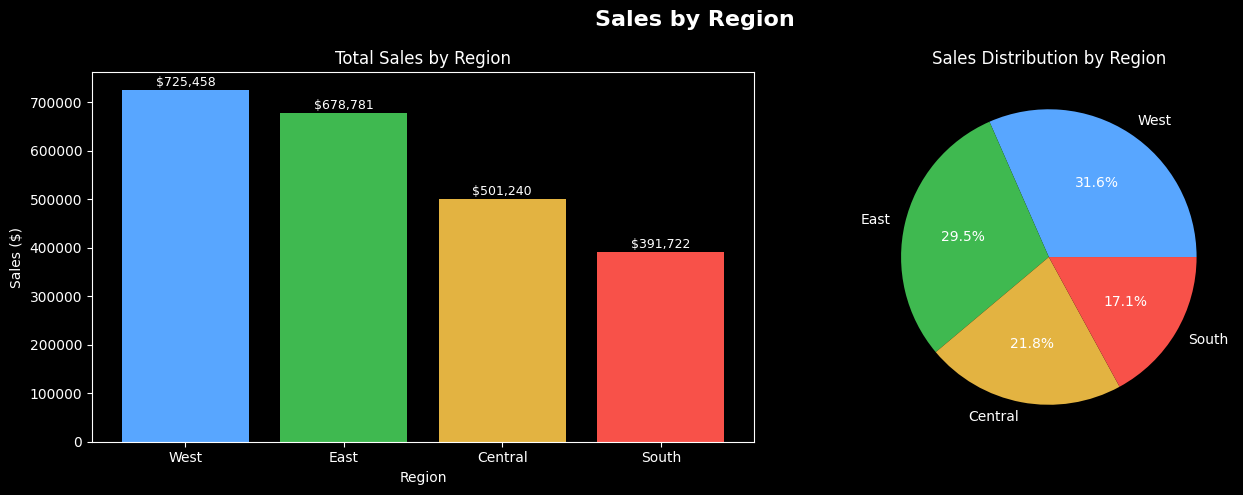

    Region        Sales  Percentage
0     West  725457.8245       31.58
1     East  678781.2400       29.55
2  Central  501239.8908       21.82
3    South  391721.9050       17.05


In [18]:
# Step 5 — Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
region_sales['Percentage'] = (region_sales['Sales'] / region_sales['Sales'].sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales by Region', fontsize=16, fontweight='bold', color='white')

# Bar chart
bars = axes[0].bar(region_sales['Region'], region_sales['Sales'],
                    color=['#58a6ff','#3fb950','#e3b341','#f85149'])
axes[0].set_title('Total Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Sales ($)')
for bar, val in zip(bars, region_sales['Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=9, color='white')

# Pie chart
axes[1].pie(region_sales['Sales'], labels=region_sales['Region'],
            autopct='%1.1f%%', colors=['#58a6ff','#3fb950','#e3b341','#f85149'])
axes[1].set_title('Sales Distribution by Region')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '01_sales_by_region.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(region_sales)

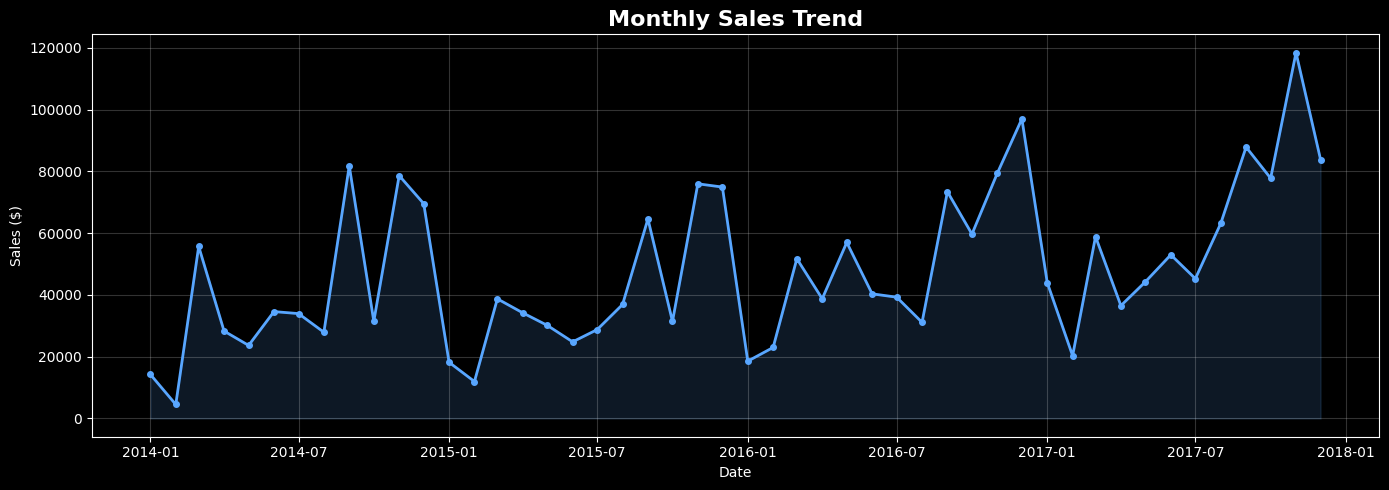

Peak month: November 2017
Peak sales: $ 118447.82


In [24]:
# Step 6 — Monthly Sales Trend
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))
monthly = monthly.sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Date'], monthly['Sales'], color='#58a6ff', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['Date'], monthly['Sales'], alpha=0.15, color='#58a6ff')
ax.set_title('Monthly Sales Trend', fontsize=16, fontweight='bold', color='white')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '02_monthly_trend.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Peak month:', monthly.loc[monthly['Sales'].idxmax(), 'Date'].strftime('%B %Y'))
print('Peak sales: $', round(monthly['Sales'].max(), 2))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

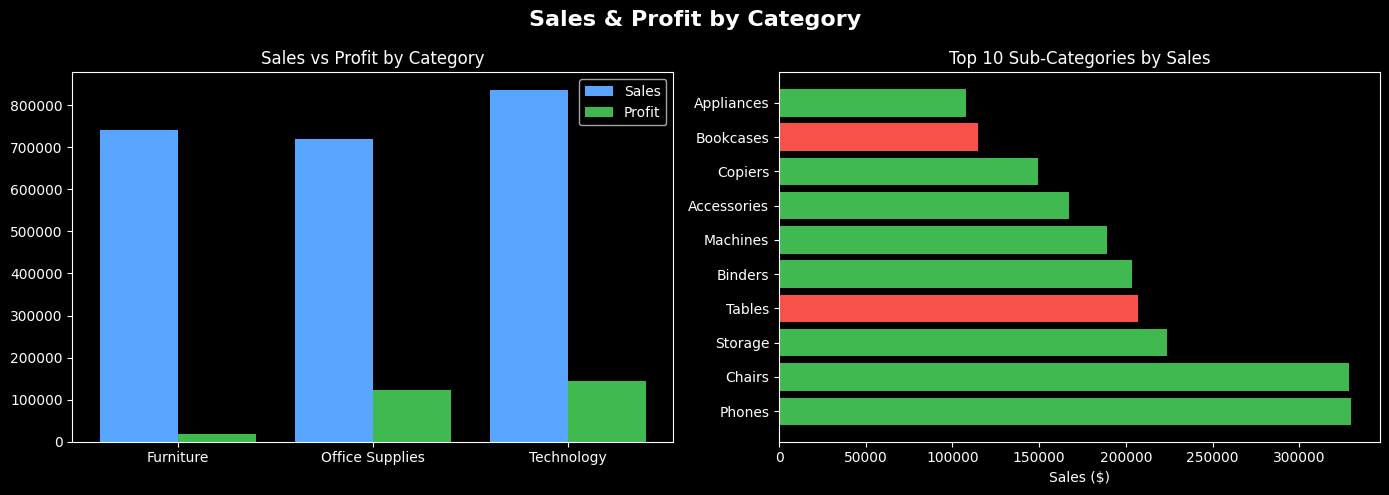

In [25]:
# Step 7 — Sales by Category and Sub-Category
category = df.groupby('Category')[['Sales','Profit']].sum().reset_index()
subcategory = df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False).head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales & Profit by Category', fontsize=16, fontweight='bold', color='white')

# Category
x = range(len(category))
axes[0].bar([i-0.2 for i in x], category['Sales'], 0.4, label='Sales', color='#58a6ff')
axes[0].bar([i+0.2 for i in x], category['Profit'], 0.4, label='Profit', color='#3fb950')
axes[0].set_xticks(x)
axes[0].set_xticklabels(category['Category'])
axes[0].set_title('Sales vs Profit by Category')
axes[0].legend()

# Sub-category
colors = ['#3fb950' if p > 0 else '#f85149' for p in subcategory['Profit']]
axes[1].barh(subcategory['Sub-Category'], subcategory['Sales'], color=colors)
axes[1].set_title('Top 10 Sub-Categories by Sales')
axes[1].set_xlabel('Sales ($)')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '03_category_analysis.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

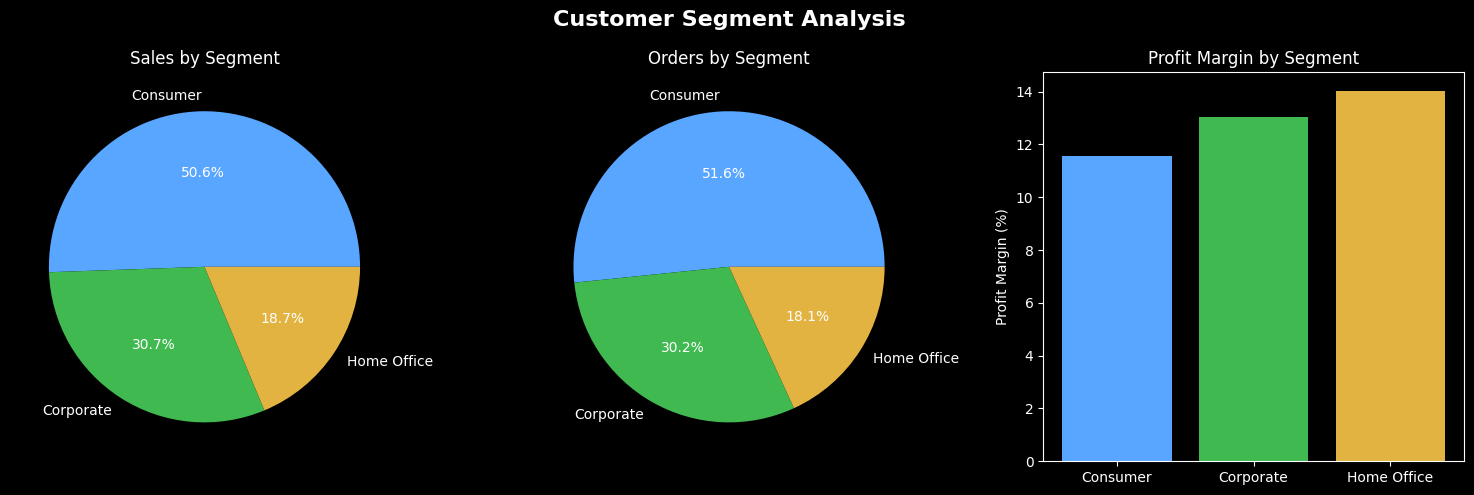

       Segment         Sales       Profit  Orders  Profit_Margin
0     Consumer  1.161401e+06  134119.2092    2586          11.55
1    Corporate  7.061464e+05   91979.1340    1514          13.03
2  Home Office  4.296531e+05   60298.6785     909          14.03


In [26]:
# Step 8 — Customer Segment Analysis
segment = df.groupby('Segment')[['Sales','Profit','Order ID']].agg(
    {'Sales':'sum', 'Profit':'sum', 'Order ID':'nunique'}
).reset_index()
segment.columns = ['Segment','Sales','Profit','Orders']
segment['Profit_Margin'] = (segment['Profit']/segment['Sales']*100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold', color='white')

colors = ['#58a6ff','#3fb950','#e3b341']
axes[0].pie(segment['Sales'], labels=segment['Segment'], autopct='%1.1f%%', colors=colors)
axes[0].set_title('Sales by Segment')

axes[1].pie(segment['Orders'], labels=segment['Segment'], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Orders by Segment')

axes[2].bar(segment['Segment'], segment['Profit_Margin'], color=colors)
axes[2].set_title('Profit Margin by Segment')
axes[2].set_ylabel('Profit Margin (%)')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '04_segment_analysis.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(segment)

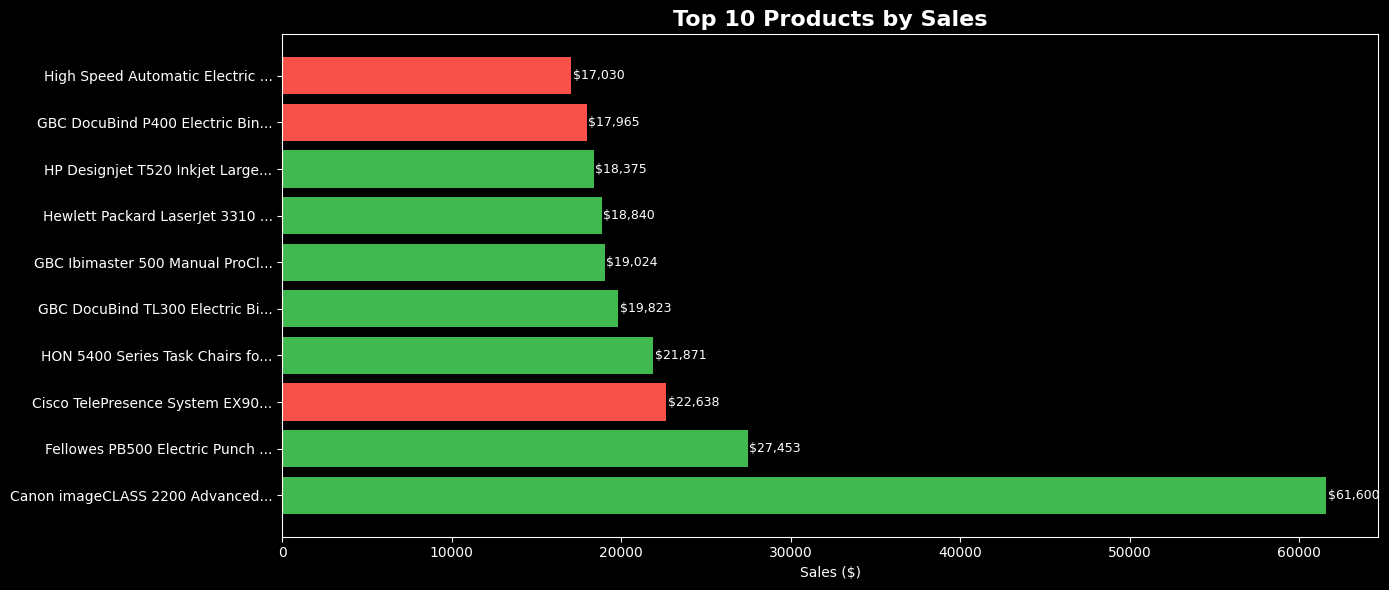

In [27]:
# Step 9 — Top 10 Products by Sales
top_products = df.groupby('Product Name')[['Sales','Profit']].sum().sort_values('Sales', ascending=False).head(10).reset_index()
top_products['Product Short'] = top_products['Product Name'].str[:30] + '...'

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_products['Product Short'], top_products['Sales'],
               color=['#3fb950' if p > 0 else '#f85149' for p in top_products['Profit']])
ax.set_title('Top 10 Products by Sales', fontsize=16, fontweight='bold', color='white')
ax.set_xlabel('Sales ($)')
for bar, val in zip(bars, top_products['Sales']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '05_top_products.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [11]:
# Step 10 — Key Business Insights
print('='*60)
print('         KEY BUSINESS INSIGHTS')
print('='*60)

# Insight 1 — Top region
top_region = df.groupby('Region')['Sales'].sum().idxmax()
top_region_pct = (df.groupby('Region')['Sales'].sum().max() / df['Sales'].sum() * 100).round(1)
print(f'\n1. {top_region} region is the top revenue contributor ({top_region_pct}% of total sales)')

# Insight 2 — Top category
top_cat = df.groupby('Category')['Sales'].sum().idxmax()
print(f'2. {top_cat} is the highest selling category')

# Insight 3 — Loss making sub-category
loss_sub = df.groupby('Sub-Category')['Profit'].sum()
loss_items = loss_sub[loss_sub < 0].index.tolist()
print(f'3. Loss-making sub-categories: {loss_items} — recommend review or discontinue')

# Insight 4 — Best segment
best_seg = df.groupby('Segment')['Profit'].sum().idxmax()
print(f'4. {best_seg} segment generates highest profit — focus marketing here')

# Insight 5 — Peak season
peak_month = df.groupby('Month')['Sales'].sum().idxmax()
import calendar
print(f'5. {calendar.month_name[peak_month]} is the peak sales month — plan inventory accordingly')

print('='*60)

         KEY BUSINESS INSIGHTS

1. West region is the top revenue contributor (31.6% of total sales)
2. Technology is the highest selling category
3. Loss-making sub-categories: ['Bookcases', 'Supplies', 'Tables'] — recommend review or discontinue
4. Consumer segment generates highest profit — focus marketing here
5. November is the peak sales month — plan inventory accordingly
